In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.calibration import calibration_curve
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    log_loss,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set()

# Paleta del curso
AZUL = "#007aff"
MAGENTA = "#ff48fd"
VERDE = "#44c57f"
NARANJA = "#ffa600"
CELESTE = "#8ecae6"
GRIS = "#555555"

# Calibración en producción: predicción de CTR en AdTech
**Aprendizaje de Máquina - CEIA - FIUBA**

En esta notebook auxiliar seguimos un caso de negocio completo, de punta a punta: un modelo que **clasifica muy
bien** pero cuyas probabilidades están tan distorsionadas que hacen perder dinero de forma sistemática. Vamos a
diagnosticar el problema, **ponerle un número en pesos** y arreglarlo.

## El problema de negocio

Trabajamos en **AdTech Solutions Inc.**, una empresa de publicidad digital en tiempo real.

Cuando un usuario entra a un sitio web, se abre una subasta por el espacio publicitario y hay milisegundos para
decidir **cuánto ofertar** por esa impresión. La regla de negocio es simple:

$$\text{Oferta} = \text{Valor del clic} \times P(\text{clic})$$

Si un clic vale $\$5$ y el modelo estima $P(\text{clic}) = 0.8$, ofertamos $\$4$. Es la oferta que deja el negocio
en equilibrio: en promedio, pagamos exactamente lo que la impresión vale.

Y acá está el punto de toda la clase: **esa fórmula no usa la clase predicha, usa la probabilidad como número**. No
alcanza con saber si el usuario va a clickear o no; hace falta saber con qué probabilidad, y que ese número sea real.

- Si el modelo dice $0.8$ y la verdad es $0.2$, ofertamos $\$4$ por algo que vale $\$1$: **quemamos presupuesto**.
- Si el modelo dice $0.3$ y la verdad es $0.9$, ofertamos poco, perdemos la subasta y **dejamos pasar al mejor
  usuario**.

Multiplicado por millones de impresiones diarias, un modelo descalibrado es un problema de plata, no de métricas.

## Los datos

Tenemos 20 features ya limpias y procesadas, agrupadas en tres bloques:

**Perfil del usuario**
`recency` (minutos desde la última visita), `click_hist` (clics en la última hora), `spend_power` (nivel
socioeconómico estimado), `device_price_idx`, `loyalty_score`, `session_depth`, `category_affinity`,
`conversion_propensity`, `scroll_velocity`, `bounce_risk`.

**Calidad del anuncio**
`keyword_match` (coincidencia con lo que el usuario buscó), `fatigue` (cuántas veces ya vio el banner),
`color_contrast_score`.

**Contexto técnico**
`domain_authority`, `load_time`, `visibility` (porcentaje del banner en pantalla), `bot_likelihood`,
`connection_speed_idx`, `competitor_density`, `hour_value_idx`.

El target es `target`: si el usuario clickeó o no.

In [2]:
data = pd.read_csv("data/clicks_ads.csv")
data.head()

,recency,click_hist,spend_power,device_price_idx,loyalty_score,session_depth,category_affinity,conversion_propensity,scroll_velocity,bounce_risk,...,fatigue,load_time,visibility,color_contrast_score,domain_authority,bot_likelihood,connection_speed_idx,competitor_density,hour_value_idx,target
0,60.338889,6.0,0.699025,1.047764,1.134747,0.210519,0.190640,0.331587,1.367512,-1.024790,...,2.0,-1.118389,0.930330,1.062015,1323.450468,0.881021,0.982265,-0.907521,1.964466,0
1,34.906080,6.0,0.473416,0.299884,0.376124,-2.347557,0.413760,-1.273831,-0.659536,-0.204922,...,1.0,-0.227337,1.671783,-1.047382,1495.575986,1.000000,-2.116978,-0.098741,-1.182179,0
2,24.176078,4.0,0.612361,-0.713168,-0.735566,-0.818127,1.013471,-1.206919,-1.684204,0.760893,...,1.0,1.666852,-0.274298,-1.691622,1302.535940,0.655795,2.424589,0.733132,0.668619,0
3,35.371190,1.0,0.708628,-2.275218,-2.548043,-0.851356,0.148650,1.517657,-1.251413,2.080829,...,3.0,-1.746989,1.543785,-0.096898,506.465695,0.826780,2.631118,1.707462,-0.961052,0
4,34.659735,3.0,0.505541,-1.473286,-1.635398,-0.995273,-0.407554,0.594795,-1.108204,1.372464,...,2.0,2.055730,1.542250,-0.445759,824.672564,0.755121,0.375396,1.151277,-0.156499,0


In [3]:
data.shape

(100000, 21)

In [4]:
X = data.drop(columns="target")
y = data["target"]

tasa_clic = y.mean()
print(f"Impresiones: {len(y):,}")
print(f"Tasa de clic (CTR real): {tasa_clic:.4f}  ({tasa_clic:.2%})")

Impresiones: 100,000
Tasa de clic (CTR real): 0.1042  (10.42%)


Un CTR del $10\%$. Guardemos ese número: es contra el que vamos a comparar todo lo que prediga el modelo.

Separamos en entrenamiento y testeo.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print(f"Train: {len(y_train):,} | Test: {len(y_test):,}")

Train: 70,000 | Test: 30,000


## El modelo que ya está en producción

Un colega implementó un **SVM lineal** para predecir si el usuario va a clickear. Veamos qué tal funciona.

In [6]:
from sklearn.svm import LinearSVC

model_svc = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LinearSVC(random_state=42)),
])

model_svc.fit(X_train, y_train)

,steps,"[('scaler', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001


In [7]:
y_pred = model_svc.predict(X_test)
report_svc = classification_report(y_test, y_pred, digits=3)
print(report_svc)

              precision    recall  f1-score   support

           0      0.943     0.988     0.965     26875
           1      0.825     0.488     0.613      3125

    accuracy                          0.936     30000
   macro avg      0.884     0.738     0.789     30000
weighted avg      0.931     0.936     0.928     30000



Como **clasificador** el modelo es bueno. Con una clase positiva que es apenas el $10\%$, consigue un recall y una
precision razonables.

El problema es otro: **el SVM no produce probabilidades**. Optimiza el margen geométrico, y su salida natural es la
distancia con signo al hiperplano separador.

In [8]:
scores = model_svc.decision_function(X_test)

print(f"decision_function: min = {scores.min():.3f}, max = {scores.max():.3f}")
print(f"¿Está en [0, 1]? {bool((scores >= 0).all() and (scores <= 1).all())}")

decision_function: min = -2.922, max = 1.766
¿Está en [0, 1]? False


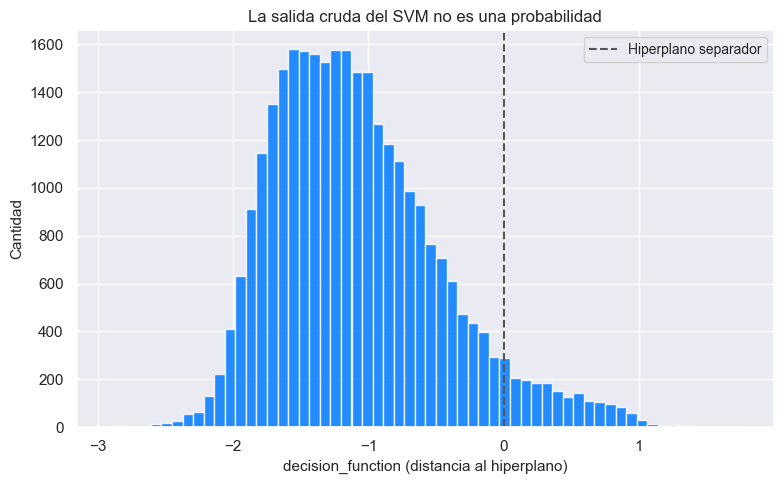

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scores, bins=60, color=AZUL, alpha=0.85)
ax.axvline(0, color=GRIS, linestyle="--", lw=1.5, label="Hiperplano separador")
ax.set_xlabel("decision_function (distancia al hiperplano)", fontsize=11)
ax.set_ylabel("Cantidad", fontsize=11)
ax.set_title("La salida cruda del SVM no es una probabilidad", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

Valores de $-2.9$ a $1.8$. No están acotados en $[0,1]$, y nada garantiza que un punto al doble de distancia sea
"el doble de probable".

### La propuesta del colega

Ante ese problema, el colega propone pasar la distancia por una sigmoide y dividir por el máximo para que quede
entre $0$ y $1$:

In [10]:
def get_probs(model, x_data):
    scores = model.decision_function(x_data)
    values = 1 / (1 + np.exp(-scores))   # sigmoide para llevar a (0, 1)
    return values / values.max()          # se normaliza para que el máximo sea 1


probs_hack = get_probs(model_svc, X_test)

print(f"Rango: [{probs_hack.min():.4f}, {probs_hack.max():.4f}]")
print(f"Media de las 'probabilidades': {probs_hack.mean():.4f}")
print(f"CTR real en test:              {y_test.mean():.4f}")

Rango: [0.0598, 1.0000]
Media de las 'probabilidades': 0.3137
CTR real en test:              0.1042


Ya sin mirar ninguna curva hay un problema evidente: **el modelo predice en promedio un $31\%$ de probabilidad de
clic, cuando la tasa real es del $10\%$**. Está sobreestimando por un factor de tres.

Y el motivo es que esa transformación **no aprendió nada de los datos**. La sigmoide $1/(1+e^{-s})$ es una fórmula
fija: convierte cualquier número real en algo entre $0$ y $1$, pero nada la ata a las frecuencias observadas. La
división por el máximo es todavía más arbitraria: depende de un único punto, el más extremo del conjunto.

> Que un número esté entre $0$ y $1$ no lo convierte en una probabilidad.

Veámoslo con la curva de calibración. Definimos las dos herramientas que vamos a usar en toda la notebook.

In [11]:
def expected_calibration_error(y_true, probs, n_bins=10):
    """Distancia media a la diagonal, ponderada por el tamaño de cada bin."""
    y_true = np.asarray(y_true)
    bordes = np.linspace(0, 1, n_bins + 1)
    idx = np.clip(np.digitize(probs, bordes[1:-1]), 0, n_bins - 1)

    ece = 0.0
    for b in range(n_bins):
        mask = idx == b
        if not mask.any():
            continue
        ece += mask.sum() / len(probs) * abs(y_true[mask].mean() - probs[mask].mean())
    return ece


def plot_calibracion(y_true, probs_dict, colores,
                     titulo="Curva de calibración", n_bins=15):
    fig, (ax, ax_hist) = plt.subplots(
        2, 1, figsize=(8, 7.5), sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.07})

    ax.plot([0, 1], [0, 1], "--", lw=1.8, color=GRIS, label="Calibración perfecta")

    for (nombre, p), color in zip(probs_dict.items(), colores):
        frac_pos, mean_pred = calibration_curve(y_true, p, n_bins=n_bins)
        ax.plot(mean_pred, frac_pos, "o-", lw=2.2, markersize=6, color=color,
                markeredgecolor="white", markeredgewidth=1.1, label=nombre)
        ax_hist.hist(p, bins=np.linspace(0, 1, 61), color=color, alpha=0.6, lw=0)

    ax.set_ylabel("Frecuencia real de clic", fontsize=11)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend(fontsize=10, loc="upper left")

    ax_hist.set_xlabel("Probabilidad predicha", fontsize=11)
    ax_hist.set_ylabel("Cantidad", fontsize=11)
    ax_hist.set_yscale("log")

    plt.show()

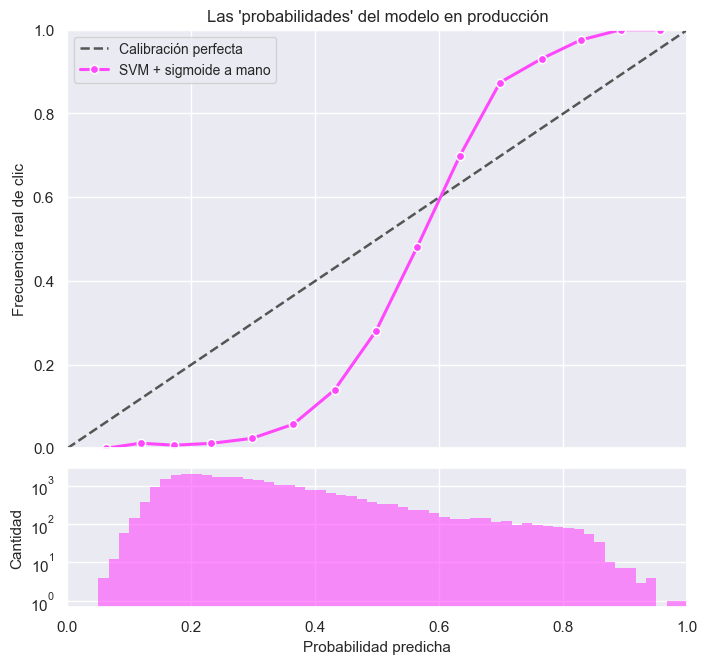

In [12]:
plot_calibracion(y_test, {"SVM + sigmoide a mano": probs_hack}, [MAGENTA],
                 "Las 'probabilidades' del modelo en producción")

La curva tiene forma de "S" muy pronunciada y **cruza la diagonal recién cerca de $0.62$**:

- **Por debajo de $0.62$ el modelo sobreestima, y de forma brutal.** Cuando promete $0.3$ de probabilidad de clic,
  la frecuencia real es de apenas $0.025$: se equivoca por un factor de doce.
- **Por encima de $0.62$ subestima**, aunque ahí el error es mucho más chico.

Ahora mirá el histograma de abajo: la enorme mayoría de las impresiones cae entre $0.1$ y $0.4$, es decir,
**justo en la zona donde el modelo miente más**. Esta es exactamente la razón por la que la curva nunca se lee sola:
sin el histograma no sabríamos si el tramo malo afecta a diez impresiones o a veinte mil.

Pongámosle números.

In [13]:
piso = tasa_clic * (1 - tasa_clic)

brier = brier_score_loss(y_test, probs_hack)
ece = expected_calibration_error(y_test, probs_hack)

print(f"Brier del modelo:                      {brier:.4f}")
print(f"Brier de predecir siempre el CTR base: {piso:.4f}")
print(f"ECE:                                   {ece:.4f}")
print(f"AUC:                                   {roc_auc_score(y_test, probs_hack):.4f}")

Brier del modelo:                      0.1042
Brier de predecir siempre el CTR base: 0.0933
ECE:                                   0.2243
AUC:                                   0.9180


Este resultado resume toda la clase en cuatro números.

El **AUC es 0.918**: el modelo ordena excelentemente, distingue muy bien a los usuarios que van a clickear de los
que no. Como clasificador es muy bueno.

Y sin embargo su **Brier Score es peor que el de predecir siempre $0.104$ a todo el mundo**. Es decir: como
estimador de probabilidad, este modelo es **peor que no tener modelo**.

Discriminación excelente, calibración desastrosa. Son propiedades independientes.

## ¿Cuánto cuesta esto en plata?

Traduzcamos el problema a la moneda del negocio. Simulamos la subasta sobre el conjunto de testeo:

- Por cada impresión ofertamos $\text{valor del clic} \times p$.
- Cobramos el valor del clic solo si el usuario efectivamente clickeó.

In [14]:
VALOR_CLIC = 5.0


def simular_subasta(y_true, probs, valor_clic=VALOR_CLIC):
    gasto = valor_clic * probs.sum()          # lo que ofertamos en total
    ingreso = valor_clic * np.asarray(y_true).sum()   # lo que realmente vale el tráfico
    return pd.Series({
        "Impresiones": len(probs),
        "Gasto (oferta)": gasto,
        "Valor real": ingreso,
        "Balance": ingreso - gasto,
        "Balance por impresión": (ingreso - gasto) / len(probs),
    })


simular_subasta(y_test, probs_hack).round(2)

Impresiones              30000.00
Gasto (oferta)           47051.29
Valor real               15625.00
Balance                 -31426.29
Balance por impresión       -1.05
dtype: float64

Sobre 30.000 impresiones ofertamos **más del triple de lo que el tráfico vale**. El balance es de unos
**$-\$31.400$**, algo más de **un dólar perdido por impresión**.

Y esto no es una pérdida de una vez: es una tasa. Una plataforma de RTB procesa millones de impresiones por día.

Veamos dónde se fuga el dinero, partiendo las impresiones en deciles de probabilidad predicha.

In [15]:
def desglose_por_decil(y_true, probs, valor_clic=VALOR_CLIC, q=10):
    d = pd.DataFrame({"p": probs, "y": np.asarray(y_true)})
    d["decil"] = pd.qcut(d["p"], q=q, labels=False, duplicates="drop")

    tabla = d.groupby("decil").agg(
        n=("y", "size"),
        p_predicha=("p", "mean"),
        ctr_real=("y", "mean"),
    )
    tabla["oferta_total"] = valor_clic * tabla["p_predicha"] * tabla["n"]
    tabla["valor_real"] = valor_clic * tabla["ctr_real"] * tabla["n"]
    tabla["balance"] = tabla["valor_real"] - tabla["oferta_total"]
    return tabla


desglose_por_decil(y_test, probs_hack).round(3)

,n,p_predicha,ctr_real,oferta_total,valor_real,balance
decil,,,,,,
0,3000,0.146,0.007,2191.608,110.0,-2081.608
1,3000,0.181,0.009,2712.677,130.0,-2582.677
2,3000,0.206,0.008,3093.895,120.0,-2973.895
3,3000,0.233,0.013,3491.445,190.0,-3301.445
4,3000,0.262,0.015,3934.275,230.0,-3704.275
5,3000,0.294,0.021,4411.542,320.0,-4091.542
6,3000,0.332,0.040,4980.510,605.0,-4375.510
7,3000,0.382,0.068,5733.762,1025.0,-4708.762
8,3000,0.457,0.191,6853.358,2865.0,-3988.358


La tabla es más interesante de lo que esperaríamos, porque el error **no** está repartido de manera uniforme.

**En el decil más alto el modelo acierta.** Predice $0.643$ y el CTR real es $0.669$: casi calibrado, y de hecho es
el único decil con balance positivo. Tiene sentido, porque son las impresiones que caen lejos del hiperplano, donde
la sigmoide fija que aplicó el colega casualmente se parece a la realidad.

**El desastre está en todo el resto.** Miremos el decil más bajo: el modelo predice $0.146$ para tráfico que
clickea el $0.7\%$ de las veces. Es una sobreestimación de **veinte veces**. Ese es el tráfico basura —bots,
usuarios que rebotan— por el que estamos pagando como si fuera tráfico decente.

**En plata, la mayor pérdida está en la zona media-alta** (deciles 6 a 8), que es donde se combinan un error grande
con ofertas altas: entre los tres se van casi $\$13.000$ de los $\$31.400$ totales.

O sea: el modelo solo sabe reconocer al usuario que seguro va a clickear. Para todo lo demás —que es el $90\%$ del
volumen— sus números no significan nada.

## Calibrando el modelo

En vez de inventar una transformación, **aprendemos** la función de calibración a partir de los datos. Usamos
`CalibratedClassifierCV`, que se encarga de todo: parte el entrenamiento en folds, entrena el SVM en $k-1$ de ellos,
predice sobre el que quedó afuera y ajusta $f_{calib}$ sobre esos scores fuera de muestra.

Notar que se le pasa el pipeline **sin entrenar**, y que funciona perfectamente sobre un modelo cuya salida no es
una probabilidad: toma la `decision_function` y la mapea a probabilidades reales.

In [16]:
from sklearn.calibration import CalibratedClassifierCV


def nuevo_svc():
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", LinearSVC(random_state=42)),
    ])


svc_platt = CalibratedClassifierCV(nuevo_svc(), method="sigmoid", cv=3)
svc_iso = CalibratedClassifierCV(nuevo_svc(), method="isotonic", cv=3)

svc_platt.fit(X_train, y_train)
svc_iso.fit(X_train, y_train)

probs = {
    "SVM + sigmoide a mano": probs_hack,
    "SVM + Platt": svc_platt.predict_proba(X_test)[:, 1],
    "SVM + Isotónica": svc_iso.predict_proba(X_test)[:, 1],
}

for nombre, p in probs.items():
    print(f"{nombre:<24} media = {p.mean():.4f}   (CTR real = {y_test.mean():.4f})")

SVM + sigmoide a mano    media = 0.3137   (CTR real = 0.1042)
SVM + Platt              media = 0.1036   (CTR real = 0.1042)
SVM + Isotónica          media = 0.1034   (CTR real = 0.1042)


Las dos versiones calibradas ahora predicen, en promedio, exactamente el CTR real. La sigmoide a mano seguía en
$0.31$.

In [17]:
def resumen(y_true, probs_dict):
    return pd.DataFrame({
        nombre: {
            "AUC": roc_auc_score(y_true, p),
            "Accuracy": accuracy_score(y_true, p >= 0.5),  # noqa: PLR2004
            "Brier": brier_score_loss(y_true, p),
            "LogLoss": log_loss(y_true, p),
            "ECE": expected_calibration_error(y_true, p),
        }
        for nombre, p in probs_dict.items()
    }).T


resumen(y_test, probs).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
SVM + sigmoide a mano,0.9180,0.9258,0.1042,0.3736,0.2243
SVM + Platt,0.9180,0.9364,0.0497,0.1807,0.0042
SVM + Isotónica,0.9179,0.9358,0.0497,0.1804,0.0022


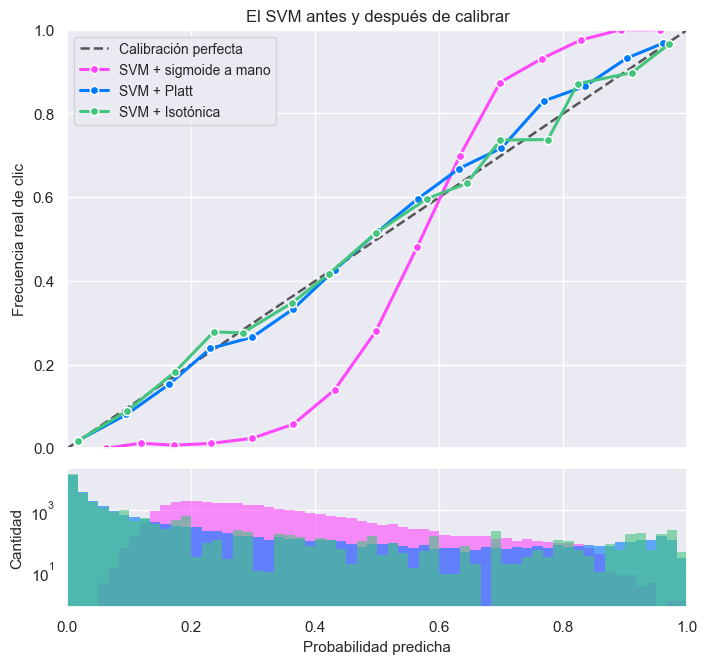

In [18]:
plot_calibracion(y_test, probs, [MAGENTA, AZUL, VERDE],
                 "El SVM antes y después de calibrar")

Las dos curvas calibradas se pegan a la diagonal. El Brier se redujo a menos de la mitad y el ECE cayó de $0.22$ a
menos de $0.005$: unas cincuenta veces mejor.

Y lo más importante para el negocio: **el AUC no se movió**. Seguimos teniendo exactamente el mismo poder de
discriminación que antes. No cambiamos el modelo, solo arreglamos la escala de sus números.

### La plata, otra vez

In [19]:
comparacion = pd.DataFrame(
    {nombre: simular_subasta(y_test, p) for nombre, p in probs.items()}).T
comparacion.round(2)

,Impresiones,Gasto (oferta),Valor real,Balance,Balance por impresión
SVM + sigmoide a mano,30000.0,47051.29,15625.0,-31426.29,-1.05
SVM + Platt,30000.0,15544.78,15625.0,80.22,0.00
SVM + Isotónica,30000.0,15517.38,15625.0,107.62,0.00


Ahí está el resultado de todo el trabajo. Los modelos calibrados ofertan un total prácticamente idéntico al valor
real del tráfico: el balance pasa de **$-\$31.400$ a casi cero**, que es exactamente lo que debe dar una oferta
justa.

Recuperamos alrededor de **un dólar por impresión**, sin cambiar el modelo, sin conseguir más datos y sin tocar
una sola feature. Solamente aprendiendo una función de una variable sobre datos que ya teníamos.

## ¿Se rompió algo del modelo original?

Es la pregunta obligada antes de llevar esto a producción. Comparemos los reportes de clasificación.

In [20]:
print("=== SVM original (sin calibrar) ===")
print(report_svc)

print("=== SVM calibrado con Platt ===")
print(classification_report(y_test, svc_platt.predict(X_test), digits=3))

=== SVM original (sin calibrar) ===
              precision    recall  f1-score   support

           0      0.943     0.988     0.965     26875
           1      0.825     0.488     0.613      3125

    accuracy                          0.936     30000
   macro avg      0.884     0.738     0.789     30000
weighted avg      0.931     0.936     0.928     30000

=== SVM calibrado con Platt ===
              precision    recall  f1-score   support

           0      0.947     0.985     0.965     26875
           1      0.797     0.523     0.631      3125

    accuracy                          0.936     30000
   macro avg      0.872     0.754     0.798     30000
weighted avg      0.931     0.936     0.930     30000



El accuracy es el mismo ($0.936$) y el $F_1$ de la clase positiva incluso mejoró un poco, de $0.613$ a $0.631$, con
un intercambio entre precision ($0.825 \to 0.797$) y recall ($0.488 \to 0.523$).

Ese cambio pequeño no significa que el modelo haya mejorado ni empeorado como clasificador: **el AUC es idéntico**,
o sea que el orden de las instancias es exactamente el mismo. Lo que pasó es que la calibración **movió los scores
respecto del umbral de $0.5$**, y algunas observaciones que estaban apenas por debajo quedaron apenas por encima.

> Se preserva el **ranking**, no las **decisiones a umbral fijo**.

La conclusión práctica es la que importa: calibrar no puso en riesgo el clasificador que ya estaba en producción.
Ganamos probabilidades utilizables sin resignar desempeño.

## La alternativa: usar un modelo que ya viene calibrado

Cabe preguntarse si todo esto se podría haber evitado usando desde el principio un modelo que optimiza
directamente la probabilidad, como la **regresión logística**.

In [21]:
from sklearn.linear_model import LogisticRegression

model_lr = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000, random_state=42)),
]).fit(X_train, y_train)

probs["Regresión logística"] = model_lr.predict_proba(X_test)[:, 1]

resumen(y_test, probs).round(4)

,AUC,Accuracy,Brier,LogLoss,ECE
SVM + sigmoide a mano,0.9180,0.9258,0.1042,0.3736,0.2243
SVM + Platt,0.9180,0.9364,0.0497,0.1807,0.0042
SVM + Isotónica,0.9179,0.9358,0.0497,0.1804,0.0022
Regresión logística,0.9188,0.9358,0.0498,0.1807,0.0037


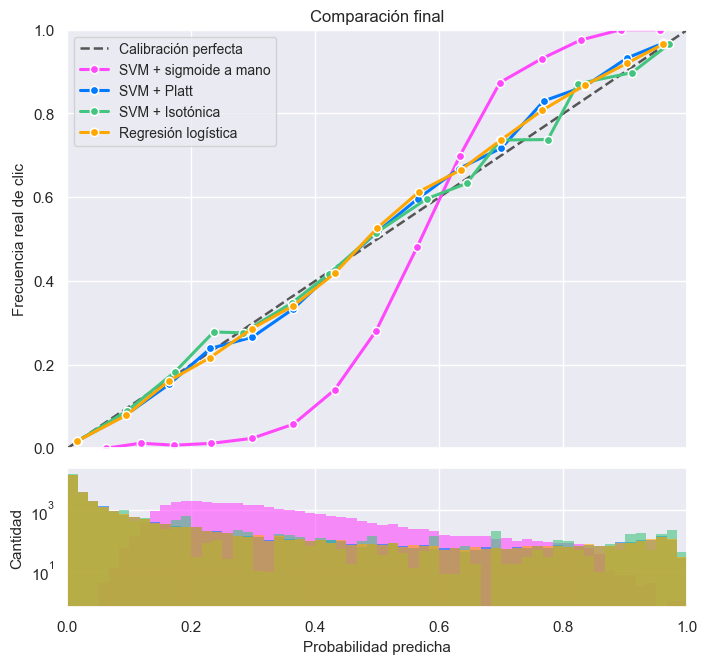

In [22]:
plot_calibracion(y_test, probs, [MAGENTA, AZUL, VERDE, NARANJA],
                 "Comparación final")

La regresión logística llega esencialmente al mismo lugar que el SVM calibrado: mismo AUC, mismo Brier, mismo ECE.
Lo cual tiene sentido, porque ambos ajustan una frontera lineal; la diferencia está en qué optimizan, y la logística
optimiza directamente la verosimilitud.

Entonces, ¿cuál conviene? Depende de la situación:

- Si estás **empezando** y una frontera lineal te alcanza, la regresión logística te ahorra el paso de calibración.
- Si ya tenés un modelo **en producción**, costoso de reentrenar, o si el mejor modelo para tu problema no es
  probabilístico (SVM, y también árboles, boosting o redes), calibrar es la vía práctica: es barato, no toca el
  modelo original y no arriesga su desempeño.

Lo que **no** es una opción es la sigmoide a mano del principio.

## Cierre

El recorrido de esta notebook:

1. Un modelo con **AUC de 0.918** —muy bueno clasificando— tenía probabilidades tan malas que su Brier Score era
   **peor que el de predecir el CTR promedio a todo el mundo**.
2. El problema venía de aplicar una transformación **fija** (sigmoide + normalización) en vez de **aprender** la
   función de calibración a partir de los datos. Que un número esté entre $0$ y $1$ no lo convierte en probabilidad.
3. Traducido a plata: sobre 30.000 impresiones, ofertar con esas probabilidades costaba unos **\$31.400**, más de
   un dólar por impresión.
4. `CalibratedClassifierCV` con Platt o isotónica corrigió el problema **sin tocar el AUC ni el reporte de
   clasificación**, y llevó el balance económico prácticamente a cero.
5. Una regresión logística habría llegado al mismo lugar sin necesidad de calibrar, pero calibrar es lo que permite
   arreglar un modelo que ya está en producción.
